# Análisis de clasificación automática de categorías constitucionales
## Proceso Constituyente Chileno 2016 — Comparación ML vs IAG

**Autor:** Álvaro Sandoval Pizarro  
**Institución:** Biblioteca del Congreso Nacional de Chile  
**Magíster en Tecnologías de Información — Universidad Técnica Federico Santa María, 2026**

Este notebook documenta y reproduce los cálculos, indicadores y gráficos incluidos en el informe final de tesis.
Los datos provienen de la base de datos PostgreSQL local que contiene los resultados del proceso de clasificación
con Machine Learning (ML, 2020) y con Inteligencia Artificial Generativa (IAG, 2025).

---
## 0. Configuración y conexión a la base de datos

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine, text
import os
from scipy import stats
from collections import Counter
from dotenv import load_dotenv

# Cargar variables de entorno desde archivo .env
load_dotenv()

# Parámetros de conexión
DB_HOST = 'localhost'
DB_PORT = '5432'
DB_NAME = 'COMPARADOR-DESAROLLO'
DB_USER = 'postgres'
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_SCHEMA = 'cabildos2016'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}',
    connect_args={'options': f'-csearch_path={DB_SCHEMA}'}
)

# Verificar conexión
with engine.connect() as conn:
    result = conn.execute(text('SELECT version()'))
    print('Conexión exitosa:', result.fetchone()[0])

Conexión exitosa: PostgreSQL 17.6 on x86_64-windows, compiled by msvc-19.44.35213, 64-bit


---
## 1. Análisis del proceso de clasificación con ML (2020)
### 1.1 Totales generales del corpus ML

In [81]:
# Total respuestas ML
sql_total_ml = """
SELECT pn.pregunta_corta, COUNT(*) AS frecuencia
FROM cab_cabildos c
JOIN cab_tipo_cabildo tc ON c.id_tipo_cabildo = tc.id_tipo_cabildo
JOIN cab_cabildos_resultados r ON c.id_cabildo = r.id_cabildo
JOIN cab_preguntas_normalizadas pn ON pn.id_pregunta_normalizada = r.id_pregunta_normalizada
WHERE r.id_pregunta_normalizada = ANY(ARRAY[1,2,3,4])
GROUP BY pn.pregunta_corta
ORDER BY pn.pregunta_corta
"""

# Total respuestas válidas ML
sql_validas_ml = """
SELECT pn.pregunta_corta, COUNT(*) AS frecuencia
FROM cab_cabildos c
JOIN cab_tipo_cabildo tc ON c.id_tipo_cabildo = tc.id_tipo_cabildo
JOIN cab_cabildos_resultados r ON c.id_cabildo = r.id_cabildo AND NOT r.ind_eliminado
JOIN cab_preguntas_normalizadas pn ON pn.id_pregunta_normalizada = r.id_pregunta_normalizada
WHERE r.id_pregunta_normalizada = ANY(ARRAY[1,2,3,4])
GROUP BY pn.pregunta_corta
ORDER BY pn.pregunta_corta
"""

# Total respuestas 'otros' ML
sql_otros_ml = """
SELECT pn.pregunta_corta, COUNT(*) AS frecuencia
FROM cab_cabildos c
JOIN cab_tipo_cabildo tc ON c.id_tipo_cabildo = tc.id_tipo_cabildo
JOIN cab_cabildos_resultados r ON c.id_cabildo = r.id_cabildo AND NOT r.ind_eliminado
JOIN cab_preguntas_normalizadas pn ON pn.id_pregunta_normalizada = r.id_pregunta_normalizada
WHERE r.id_pregunta_normalizada = ANY(ARRAY[1,2,3,4])
AND r.ind_otro = true
GROUP BY pn.pregunta_corta
ORDER BY pn.pregunta_corta
"""

with engine.connect() as conn:
    df_total = pd.read_sql(sql_total_ml, conn)
    df_validas = pd.read_sql(sql_validas_ml, conn)
    df_otros = pd.read_sql(sql_otros_ml, conn)

print('Total respuestas ML por metacategoría:')
print(df_total)
print(f'\nTotal general: {df_total["frecuencia"].sum():,}')
print(f'Total válidas: {df_validas["frecuencia"].sum():,}')
print(f'Total otros: {df_otros["frecuencia"].sum():,}')

Total respuestas ML por metacategoría:
                pregunta_corta  frecuencia
0  Deberes y Responsabilidades       62861
1                     Derechos       68329
2                Instituciones       63911
3         Valores y Principios       69253

Total general: 264,354
Total válidas: 264,087
Total otros: 36,026


### 1.2 Clasificación manual por metacategoría

In [82]:
# Total respuestas clasificadas manualmente
sql_manual = """
SELECT pn.pregunta_corta, COUNT(*) AS frecuencia
FROM cab_cabildos c
JOIN cab_tipo_cabildo tc ON c.id_tipo_cabildo = tc.id_tipo_cabildo
JOIN cab_cabildos_resultados r ON c.id_cabildo = r.id_cabildo AND NOT r.ind_eliminado
JOIN cab_preguntas_normalizadas pn ON pn.id_pregunta_normalizada = r.id_pregunta_normalizada
WHERE r.id_pregunta_normalizada = ANY(ARRAY[1,2,3,4])
AND r.ind_otro = true
AND r.ind_otro_manual = true
GROUP BY pn.pregunta_corta
ORDER BY pn.pregunta_corta
"""

with engine.connect() as conn:
    df_manual = pd.read_sql(sql_manual, conn)
    df_otros2 = pd.read_sql(sql_otros_ml, conn)

df_manual_resumen = df_otros2.merge(df_manual, on='pregunta_corta', suffixes=('_otros', '_manual'))
df_manual_resumen['pct_manual'] = (df_manual_resumen['frecuencia_manual'] / df_manual_resumen['frecuencia_otros'] * 100).round(1)

print('Clasificación manual por metacategoría:')
print(df_manual_resumen.to_string(index=False))
total_otros = df_manual_resumen['frecuencia_otros'].sum()
total_manual = df_manual_resumen['frecuencia_manual'].sum()
print(f'\nTotal: {total_manual:,}/{total_otros:,} = {total_manual/total_otros*100:.1f}%')

Clasificación manual por metacategoría:
             pregunta_corta  frecuencia_otros  frecuencia_manual  pct_manual
Deberes y Responsabilidades              8878               1544        17.4
                   Derechos              9427               1625        17.2
              Instituciones             10573               3782        35.8
       Valores y Principios              7148               6451        90.2

Total: 13,402/36,026 = 37.2%


### 1.3 Resultado del proceso de clasificación ML

In [83]:
# Respuestas clasificadas en 1 categoría
sql_una_cat = """
SELECT pregunta_corta, SUM(frecuencia) AS frecuencia FROM
    (SELECT pn.pregunta_corta, r.id_cab_resultados, COUNT(*) AS frecuencia
    FROM cab_cabildos c
    JOIN cab_tipo_cabildo tc ON c.id_tipo_cabildo = tc.id_tipo_cabildo
    JOIN cab_cabildos_resultados r ON c.id_cabildo = r.id_cabildo AND NOT r.ind_eliminado
    JOIN cab_preguntas_normalizadas pn ON pn.id_pregunta_normalizada = r.id_pregunta_normalizada
    JOIN cab_cabildos_resultados_respuestas rr ON r.id_cab_resultados = rr.id_cab_resultados AND NOT rr.ind_eliminado
    JOIN cab_respuestas_normalizadas2 rn ON rn.id_respuesta_normalizada2 = rr.id_respuesta_normalizada2
    WHERE r.id_pregunta_normalizada = ANY(ARRAY[1,2,3,4])
    AND rr.id_respuesta_normalizada2 > 0
    AND r.ind_otro = true
    GROUP BY pn.pregunta_corta, r.id_cab_resultados
    HAVING COUNT(*) = 1) sub
GROUP BY pregunta_corta
ORDER BY pregunta_corta
"""

# Total categorías asignadas
sql_total_cats = """
SELECT pn.pregunta_corta, COUNT(*) AS frecuencia
FROM cab_cabildos c
JOIN cab_tipo_cabildo tc ON c.id_tipo_cabildo = tc.id_tipo_cabildo
JOIN cab_cabildos_resultados r ON c.id_cabildo = r.id_cabildo AND NOT r.ind_eliminado
JOIN cab_preguntas_normalizadas pn ON pn.id_pregunta_normalizada = r.id_pregunta_normalizada
JOIN cab_cabildos_resultados_respuestas rr ON r.id_cab_resultados = rr.id_cab_resultados AND NOT rr.ind_eliminado
JOIN cab_respuestas_normalizadas2 rn ON rn.id_respuesta_normalizada2 = rr.id_respuesta_normalizada2
WHERE r.id_pregunta_normalizada = ANY(ARRAY[1,2,3,4])
AND rr.id_respuesta_normalizada2 > 0
AND r.ind_otro = true
GROUP BY pn.pregunta_corta
ORDER BY pn.pregunta_corta
"""

# Categorías originales vs nuevas
sql_originales = """
SELECT pn.pregunta_corta, COUNT(*) AS frecuencia
FROM cab_cabildos c
JOIN cab_tipo_cabildo tc ON c.id_tipo_cabildo = tc.id_tipo_cabildo
JOIN cab_cabildos_resultados r ON c.id_cabildo = r.id_cabildo AND NOT r.ind_eliminado
JOIN cab_preguntas_normalizadas pn ON pn.id_pregunta_normalizada = r.id_pregunta_normalizada
JOIN cab_cabildos_resultados_respuestas rr ON r.id_cab_resultados = rr.id_cab_resultados AND NOT rr.ind_eliminado
JOIN cab_respuestas_normalizadas2 rn ON rn.id_respuesta_normalizada2 = rr.id_respuesta_normalizada2
WHERE r.id_pregunta_normalizada = ANY(ARRAY[1,2,3,4])
AND rr.id_respuesta_normalizada2 > 0
AND r.ind_otro = true
AND rn.ind_otros = 0
GROUP BY pn.pregunta_corta
ORDER BY pn.pregunta_corta
"""

sql_nuevas = """
SELECT pn.pregunta_corta, COUNT(*) AS frecuencia
FROM cab_cabildos c
JOIN cab_tipo_cabildo tc ON c.id_tipo_cabildo = tc.id_tipo_cabildo
JOIN cab_cabildos_resultados r ON c.id_cabildo = r.id_cabildo AND NOT r.ind_eliminado
JOIN cab_preguntas_normalizadas pn ON pn.id_pregunta_normalizada = r.id_pregunta_normalizada
JOIN cab_cabildos_resultados_respuestas rr ON r.id_cab_resultados = rr.id_cab_resultados AND NOT rr.ind_eliminado
JOIN cab_respuestas_normalizadas2 rn ON rn.id_respuesta_normalizada2 = rr.id_respuesta_normalizada2
WHERE r.id_pregunta_normalizada = ANY(ARRAY[1,2,3,4])
AND rr.id_respuesta_normalizada2 > 0
AND r.ind_otro = true
AND rn.ind_otros = 1
GROUP BY pn.pregunta_corta
ORDER BY pn.pregunta_corta
"""

with engine.connect() as conn:
    df_una = pd.read_sql(sql_una_cat, conn)
    df_total_cats = pd.read_sql(sql_total_cats, conn)
    df_orig = pd.read_sql(sql_originales, conn)
    df_nuevas = pd.read_sql(sql_nuevas, conn)

print('Total asignaciones ML por metacategoría:')
print(df_total_cats)
print(f'\nTotal asignaciones: {df_total_cats["frecuencia"].sum():,}')
print(f'Con 1 categoría: {df_una["frecuencia"].sum():,}')
print(f'Categorías originales: {df_orig["frecuencia"].sum():,}')
print(f'Categorías nuevas: {df_nuevas["frecuencia"].sum():,}')
total_cats = df_total_cats['frecuencia'].sum()
total_nuevas = df_nuevas['frecuencia'].sum()
print(f'% categorías nuevas: {total_nuevas/total_cats*100:.1f}%')

Total asignaciones ML por metacategoría:
                pregunta_corta  frecuencia
0  Deberes y Responsabilidades        8009
1                     Derechos        9393
2                Instituciones        9906
3         Valores y Principios        7869

Total asignaciones: 35,177
Con 1 categoría: 29,111.0
Categorías originales: 16,154
Categorías nuevas: 19,023
% categorías nuevas: 54.1%


---
## 2. Análisis del proceso de clasificación con IAG (2025)
### 2.1 Cobertura IAG

In [84]:
sql_iag_cobertura = """
SELECT
    COUNT(*) AS total_registros,
    COUNT(CASE WHEN id_categoria > 0 THEN 1 END) AS clasificados,
    COUNT(CASE WHEN id_categoria <= 0 THEN 1 END) AS no_clasificados,
    ROUND(COUNT(CASE WHEN id_categoria > 0 THEN 1 END) * 100.0 / COUNT(*), 2) AS pct_clasificados
FROM mti_resultados_integrados
WHERE ind_otro_respuesta = true
"""

with engine.connect() as conn:
    df_iag_cob = pd.read_sql(sql_iag_cobertura, conn)

print('Cobertura del proceso IAG:')
print(df_iag_cob.to_string(index=False))

Cobertura del proceso IAG:
 total_registros  clasificados  no_clasificados  pct_clasificados
           36296         36088                3             99.43


### 2.2 Categorías originales vs emergentes IAG

In [85]:
sql_iag_cats = """
SELECT
    pregunta,
    COUNT(*) AS total_asignaciones,
    COUNT(CASE WHEN ind_otro_clasificacion = 0 THEN 1 END) AS originales,
    COUNT(CASE WHEN ind_otro_clasificacion = 1 THEN 1 END) AS nuevas,
    ROUND(COUNT(CASE WHEN ind_otro_clasificacion = 1 THEN 1 END) * 100.0 / COUNT(*), 1) AS pct_nuevas
FROM mti_resultados_integrados
WHERE ind_otro_respuesta = true
AND id_categoria > 0
GROUP BY pregunta
ORDER BY pregunta
"""

with engine.connect() as conn:
    df_iag_cats = pd.read_sql(sql_iag_cats, conn)

print('Categorías originales vs emergentes IAG:')
print(df_iag_cats.to_string(index=False))

Categorías originales vs emergentes IAG:
                   pregunta  total_asignaciones  originales  nuevas  pct_nuevas
Deberes y Responsabilidades                8884        2356    6528        73.5
                   Derechos                9436        4600    4836        51.3
              Instituciones               10622        4622    6000        56.5
       Valores y Principios                7146        3087    4059        56.8


---
## 3. Análisis comparativo ML vs IAG
### 3.1 Coincidencia exacta entre ML e IAG

In [86]:
sql_coincidencia = """
SELECT
    COUNT(*) AS total_comparables,
    COUNT(CASE WHEN rr.id_respuesta_normalizada2 = iag.id_categoria THEN 1 END) AS coincidencias_exactas,
    ROUND(
        COUNT(CASE WHEN rr.id_respuesta_normalizada2 = iag.id_categoria THEN 1 END) * 100.0 / COUNT(*), 1
    ) AS pct_coincidencia
FROM mti_resultados_integrados iag
JOIN cab_cabildos_resultados r ON iag.id_cab_resultados = r.id_cab_resultados
JOIN cab_cabildos_resultados_respuestas rr ON r.id_cab_resultados = rr.id_cab_resultados
    AND NOT rr.ind_eliminado
WHERE iag.ind_otro_respuesta = true
AND iag.id_categoria > 0
AND rr.id_respuesta_normalizada2 > 0
"""

with engine.connect() as conn:
    df_coincidencia = pd.read_sql(sql_coincidencia, conn)

print('Coincidencia exacta ML vs IAG:')
print(df_coincidencia.to_string(index=False))

Coincidencia exacta ML vs IAG:
 total_comparables  coincidencias_exactas  pct_coincidencia
             35189                  20973              59.6


---
## 4. Diversidad distributiva
### 4.1 Índices de Shannon, Simpson y número efectivo de categorías

In [87]:
# Frecuencias ML
sql_freq_ml = """
SELECT rr.id_respuesta_normalizada2 AS id_categoria, COUNT(*) AS frecuencia
FROM cab_cabildos_resultados r
JOIN cab_cabildos_resultados_respuestas rr ON r.id_cab_resultados = rr.id_cab_resultados
    AND NOT rr.ind_eliminado
WHERE r.id_pregunta_normalizada = ANY(ARRAY[1,2,3,4])
AND rr.id_respuesta_normalizada2 > 0
AND NOT r.ind_eliminado
GROUP BY rr.id_respuesta_normalizada2
"""

# Frecuencias IAG
sql_freq_iag = """
SELECT id_categoria, COUNT(*) AS frecuencia
FROM mti_resultados_integrados
WHERE id_categoria > 0
GROUP BY id_categoria
"""

def calcular_diversidad(df_freq):
    total = df_freq['frecuencia'].sum()
    p = df_freq['frecuencia'] / total
    shannon = -np.sum(p * np.log(p))
    efectivo = np.exp(shannon)
    simpson = 1 - np.sum(p ** 2)
    return shannon, efectivo, simpson

with engine.connect() as conn:
    df_freq_ml = pd.read_sql(sql_freq_ml, conn)
    df_freq_iag = pd.read_sql(sql_freq_iag, conn)

shannon_ml, efectivo_ml, simpson_ml = calcular_diversidad(df_freq_ml)
shannon_iag, efectivo_iag, simpson_iag = calcular_diversidad(df_freq_iag)

df_diversidad = pd.DataFrame({
    'Indicador': ['Índice de Shannon (H)', 'Número efectivo de categorías (exp(H))', 'Índice de Simpson (1-D)'],
    'ML': [round(shannon_ml, 3), round(efectivo_ml, 1), round(simpson_ml, 4)],
    'IAG': [round(shannon_iag, 3), round(efectivo_iag, 1), round(simpson_iag, 4)]
})

print('Indicadores de diversidad distributiva:')
print(df_diversidad.to_string(index=False))

Indicadores de diversidad distributiva:
                             Indicador      ML     IAG
                 Índice de Shannon (H)  4.5490  4.5880
Número efectivo de categorías (exp(H)) 94.5000 98.3000
               Índice de Simpson (1-D)  0.9854  0.9859


---
## 5. Concentración temática — Regla del 80%

In [88]:
sql_concentracion_iag = """
SELECT pregunta, id_categoria, categoria, COUNT(*) AS frecuencia
FROM mti_resultados_integrados
WHERE id_categoria > 0
GROUP BY pregunta, id_categoria, categoria
ORDER BY pregunta, frecuencia DESC
"""

with engine.connect() as conn:
    df_conc = pd.read_sql(sql_concentracion_iag, conn)

def categorias_para_80pct(df, col_grupo='pregunta'):
    resultados = []
    for grupo, subdf in df.groupby(col_grupo):
        total = subdf['frecuencia'].sum()
        subdf = subdf.sort_values('frecuencia', ascending=False).copy()
        subdf['acumulado'] = subdf['frecuencia'].cumsum() / total
        n_cats = (subdf['acumulado'] <= 0.80).sum() + 1
        total_cats = len(subdf)
        resultados.append({
            'Metacategoría': grupo,
            'Total categorías': total_cats,
            'Categorías para 80%': n_cats,
            'Proporción': f'{n_cats/total_cats*100:.1f}%'
        })
    return pd.DataFrame(resultados)

df_80 = categorias_para_80pct(df_conc)
print('Concentración temática — categorías necesarias para explicar el 80% de la frecuencia (IAG):')
print(df_80.to_string(index=False))

Concentración temática — categorías necesarias para explicar el 80% de la frecuencia (IAG):
              Metacategoría  Total categorías  Categorías para 80% Proporción
Deberes y Responsabilidades                48                    9      18.8%
                   Derechos                70                   22      31.4%
              Instituciones                82                   13      15.9%
       Valores y Principios                67                   19      28.4%


---
## 6. Gráficos de frecuencia comparada ML vs IAG
### 6.1 Valores y Principios

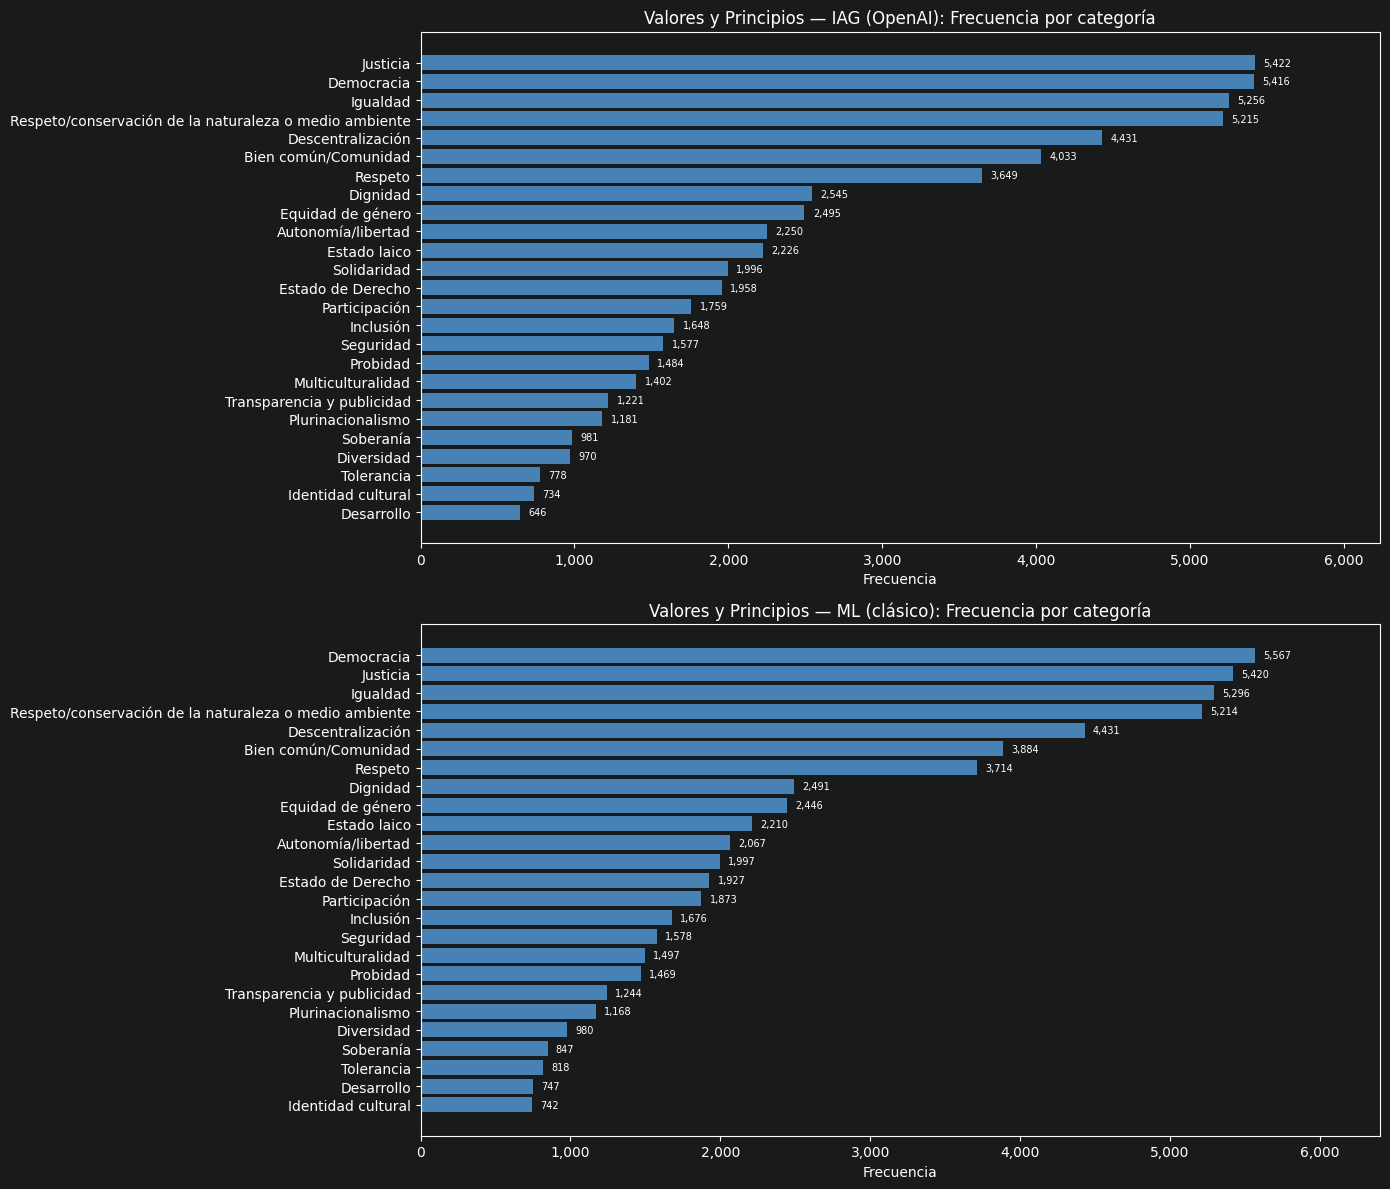

Gráfico guardado: figura_6_valores.png


In [89]:
def obtener_frecuencias_iag(engine, id_taxonomia, top_n=25):
    sql = f"""
    SELECT categoria, COUNT(*) AS frecuencia
    FROM mti_resultados_integrados
    WHERE id_taxonomia = {id_taxonomia} AND id_categoria > 0
    GROUP BY categoria
    ORDER BY frecuencia DESC
    LIMIT {top_n}
    """
    with engine.connect() as conn:
        return pd.read_sql(sql, conn)

def obtener_frecuencias_ml(engine, id_pregunta, top_n=25):
    sql = f"""
    SELECT rn.respuesta_normalizada AS categoria, COUNT(*) AS frecuencia
    FROM cab_cabildos_resultados r
    JOIN cab_cabildos_resultados_respuestas rr ON r.id_cab_resultados = rr.id_cab_resultados
        AND NOT rr.ind_eliminado
    JOIN cab_respuestas_normalizadas2 rn ON rn.id_respuesta_normalizada2 = rr.id_respuesta_normalizada2
    WHERE r.id_pregunta_normalizada = {id_pregunta}
    AND rr.id_respuesta_normalizada2 > 0
    AND NOT r.ind_eliminado
    GROUP BY rn.respuesta_normalizada
    ORDER BY frecuencia DESC
    LIMIT {top_n}
    """
    with engine.connect() as conn:
        return pd.read_sql(sql, conn)

def grafico_comparado(df_iag, df_ml, titulo, nombre_archivo):
    fig, axes = plt.subplots(2, 1, figsize=(14, 12))

    for ax, df, subtitulo in [
        (axes[0], df_iag, f'{titulo} — IAG (OpenAI): Frecuencia por categoría'),
        (axes[1], df_ml, f'{titulo} — ML (clásico): Frecuencia por categoría')
    ]:
        df_plot = df.iloc[::-1].reset_index(drop=True)
        bars = ax.barh(df_plot['categoria'], df_plot['frecuencia'], color='steelblue')
        ax.set_title(subtitulo)
        ax.set_xlabel('Frecuencia')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

        # Etiquetas de frecuencia al final de cada barra
        x_max = df_plot['frecuencia'].max()
        for bar, freq in zip(bars, df_plot['frecuencia']):
            ax.text(
                bar.get_width() + x_max * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{int(freq):,}',
                va='center', ha='left', fontsize=7
            )
        ax.set_xlim(0, x_max * 1.15)

    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Gráfico guardado: {nombre_archivo}')

# Valores y Principios (id_taxonomia=1, id_pregunta_normalizada=1)
df_iag_v = obtener_frecuencias_iag(engine, 1)
df_ml_v = obtener_frecuencias_ml(engine, 1)
grafico_comparado(df_iag_v, df_ml_v, 'Valores y Principios', 'figura_6_valores.png')

### 6.2 Derechos

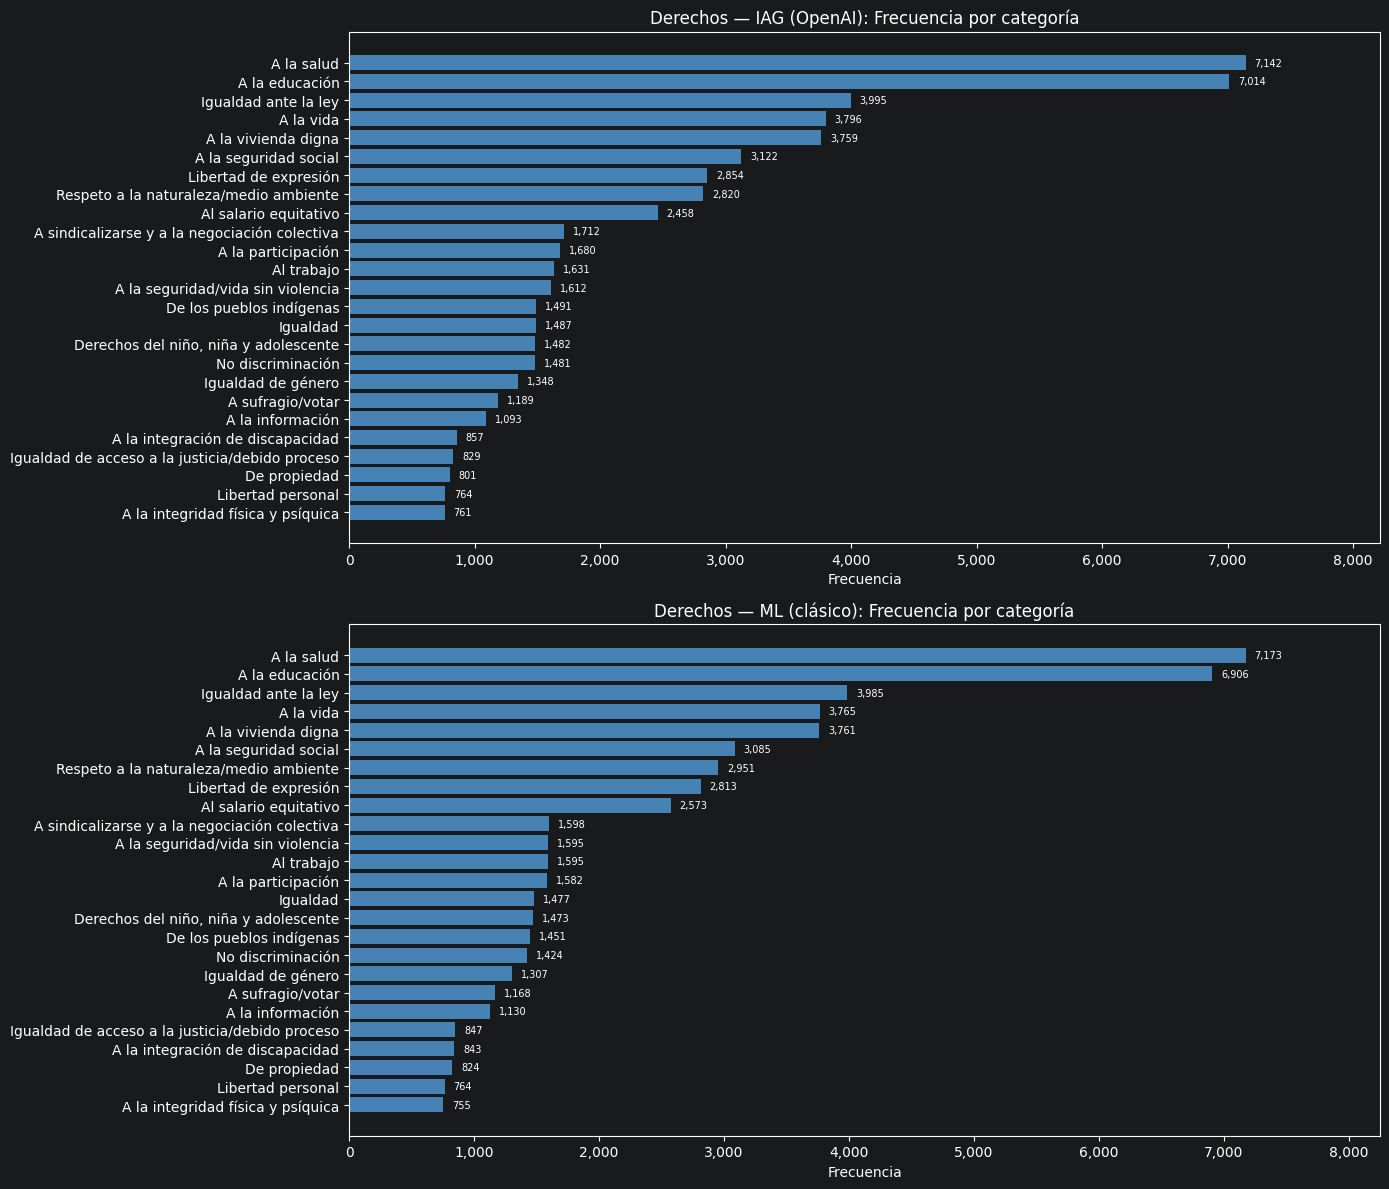

Gráfico guardado: figura_7_derechos.png


In [90]:
df_iag_d = obtener_frecuencias_iag(engine, 2)
df_ml_d = obtener_frecuencias_ml(engine, 2)
grafico_comparado(df_iag_d, df_ml_d, 'Derechos', 'figura_7_derechos.png')

### 6.3 Deberes y Responsabilidades

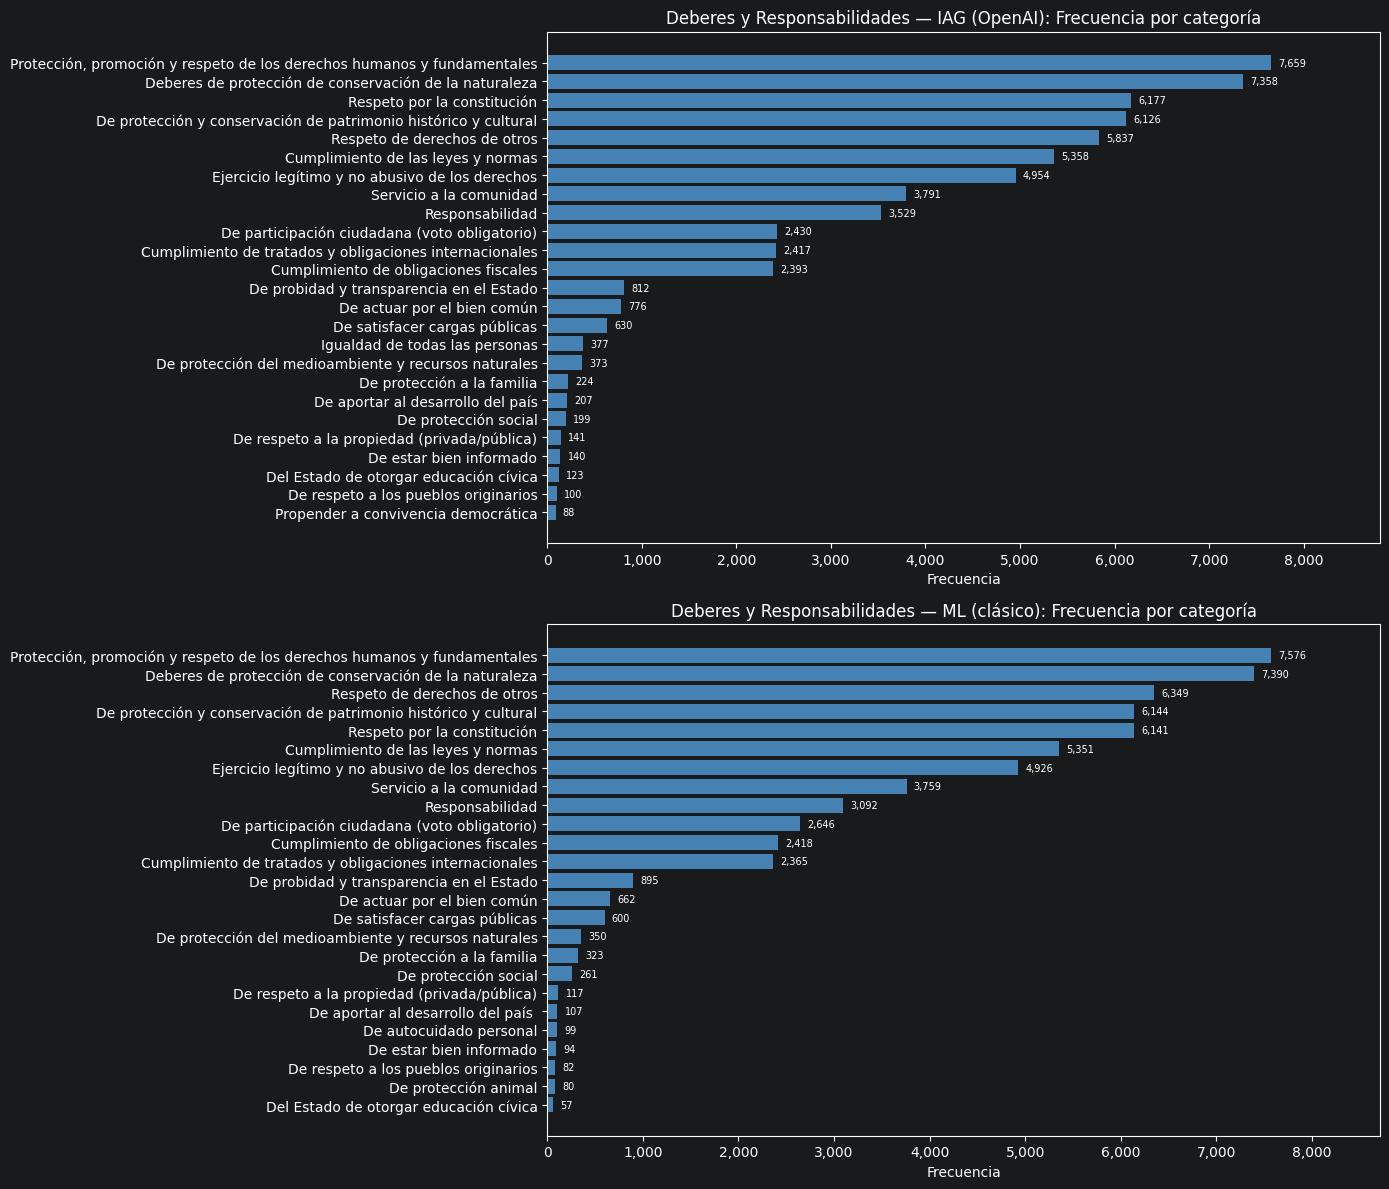

Gráfico guardado: figura_8_deberes.png


In [91]:
df_iag_db = obtener_frecuencias_iag(engine, 3)
df_ml_db = obtener_frecuencias_ml(engine, 3)
grafico_comparado(df_iag_db, df_ml_db, 'Deberes y Responsabilidades', 'figura_8_deberes.png')

### 6.4 Instituciones del Estado

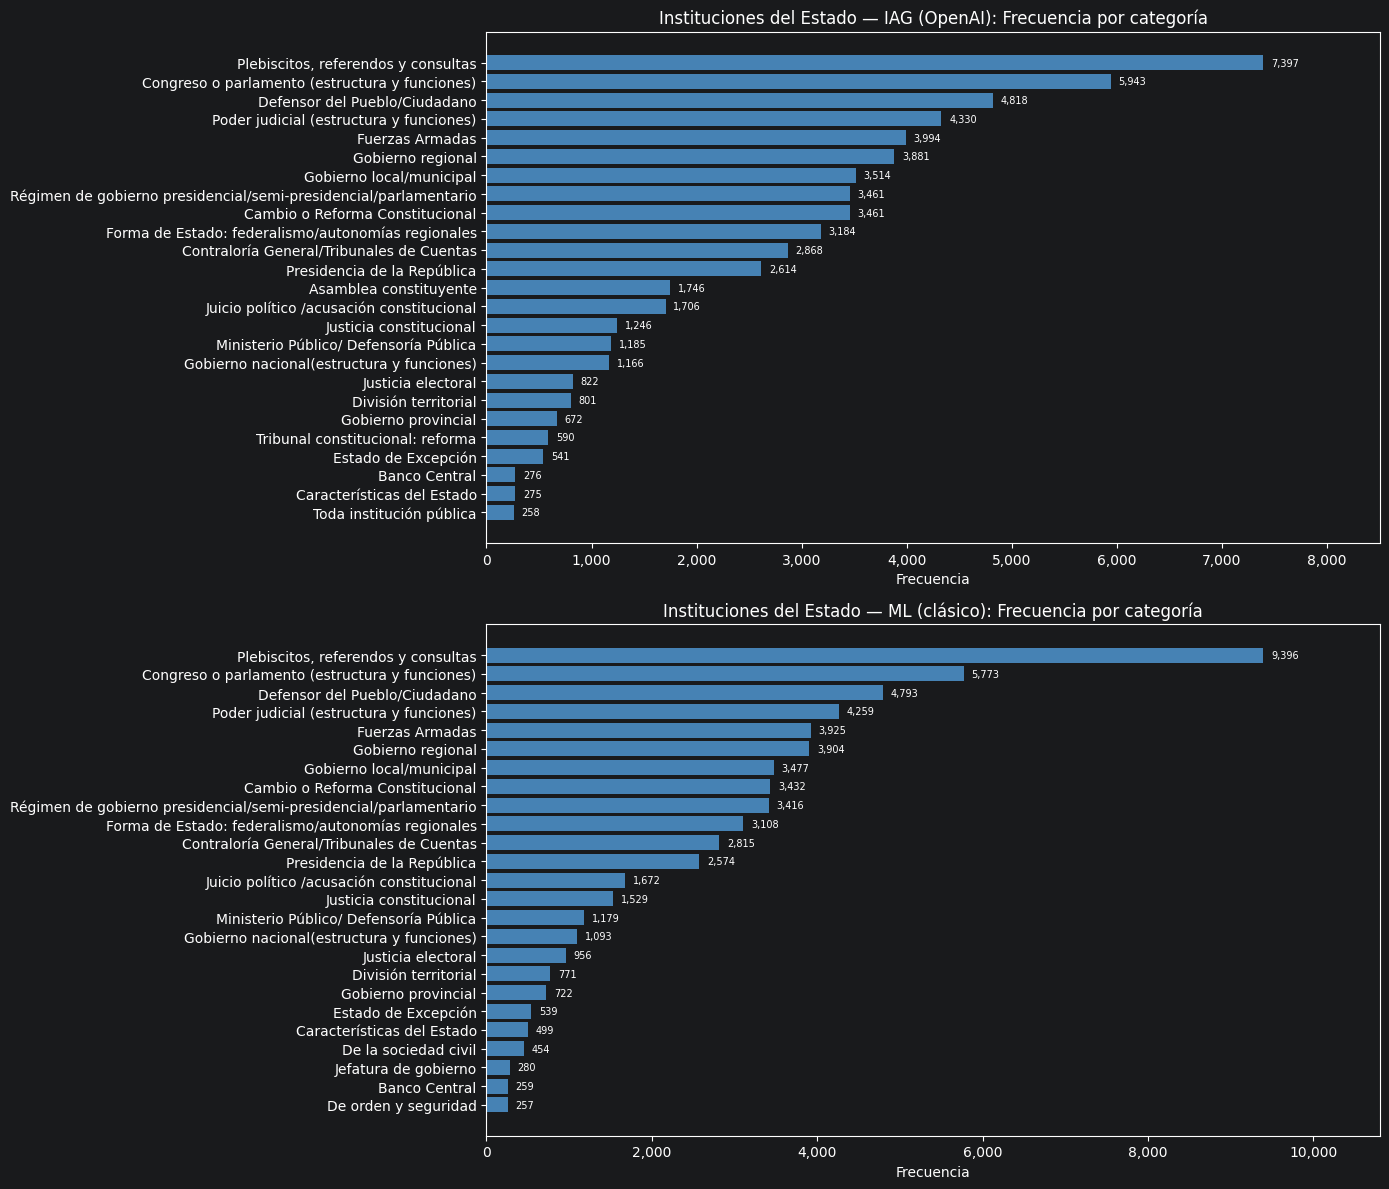

Gráfico guardado: figura_9_instituciones.png


In [92]:
df_iag_i = obtener_frecuencias_iag(engine, 4)
df_ml_i = obtener_frecuencias_ml(engine, 4)
grafico_comparado(df_iag_i, df_ml_i, 'Instituciones del Estado', 'figura_9_instituciones.png')

---
## 7. Evaluación experta — Kappa de Cohen y Kappa de Fleiss

In [93]:
# Cargar planilla de evaluación
df_eval = pd.read_excel('../evaluacion_experta/encuesta_evaluacion.xlsx')

col_e1 = 'evaluador_1'
col_e2 = 'evaluador_2'
col_e3 = 'evaluador_3'

# Extraer código numérico del string (ej: "2 IAG mejor" -> 2)
def extraer_codigo(valor):
    try:
        return int(str(valor).strip()[0])
    except:
        return None

df_eval['cod_e1'] = df_eval[col_e1].apply(extraer_codigo)
df_eval['cod_e2'] = df_eval[col_e2].apply(extraer_codigo)
df_eval['cod_e3'] = df_eval[col_e3].apply(extraer_codigo)

ratings = df_eval[['cod_e1', 'cod_e2', 'cod_e3']].values
n = len(ratings)
categories = [1, 2, 3, 4, 9]

# Kappa de Cohen por par
def kappa_cohen(r1, r2):
    mask = ~(pd.isna(r1) | pd.isna(r2))
    r1, r2 = r1[mask].astype(int), r2[mask].astype(int)
    acuerdo = np.sum(r1 == r2) / len(r1)
    cats = list(set(r1) | set(r2))
    pe = sum(
        (np.sum(r1 == c) / len(r1)) * (np.sum(r2 == c) / len(r2))
        for c in cats
    )
    return acuerdo, pe, (acuerdo - pe) / (1 - pe) if pe < 1 else 0

pares = [
    ('Eval 1-2', df_eval['cod_e1'].values, df_eval['cod_e2'].values),
    ('Eval 2-3', df_eval['cod_e2'].values, df_eval['cod_e3'].values),
    ('Eval 1-3', df_eval['cod_e1'].values, df_eval['cod_e3'].values),
]

resultados_cohen = []
for nombre, r1, r2 in pares:
    po, pe, k = kappa_cohen(r1, r2)
    acuerdo_n = int(po * n)
    resultados_cohen.append({
        'Par': nombre,
        'Acuerdo observado': f'{po*100:.1f}% ({acuerdo_n}/{n})',
        'Acuerdo esperado': f'{pe*100:.1f}%',
        'Kappa de Cohen': round(k, 3)
    })

df_cohen = pd.DataFrame(resultados_cohen)
kappa_prom = df_cohen['Kappa de Cohen'].mean()
df_cohen.loc[len(df_cohen)] = ['Promedio', '', '', round(kappa_prom, 3)]

# Kappa de Fleiss
cat_to_idx = {c: i for i, c in enumerate(categories)}
nij = np.zeros((n, len(categories)), dtype=int)
for i, row in enumerate(ratings):
    for r in row:
        if r is not None and not pd.isna(r) and int(r) in cat_to_idx:
            nij[i, cat_to_idx[int(r)]] += 1

k_raters = 3
P_i = np.array([(1 / (k_raters*(k_raters-1))) * np.sum(nij[i] * (nij[i]-1)) for i in range(n)])
P_bar = np.mean(P_i)
p_j = np.sum(nij, axis=0) / (n * k_raters)
P_e = np.sum(p_j ** 2)
kappa_fleiss = (P_bar - P_e) / (1 - P_e)

df_cohen.loc[len(df_cohen)] = ['Kappa de Fleiss', f'{P_bar*100:.1f}%', f'{P_e*100:.1f}%', round(kappa_fleiss, 3)]

print('Concordancia inter-evaluador:')
print(df_cohen.to_string(index=False))

Concordancia inter-evaluador:
            Par Acuerdo observado Acuerdo esperado  Kappa de Cohen
       Eval 1-2    33.0% (66/200)            26.5%           0.089
       Eval 2-3    31.0% (62/200)            28.2%           0.039
       Eval 1-3    34.0% (68/200)            23.2%           0.140
       Promedio                                              0.089
Kappa de Fleiss             32.7%            28.5%           0.059


### 7.1 Distribución por mayoría simple (≥2 de 3 evaluadores)

In [94]:
from collections import Counter

etiquetas = {1: 'ML mejor', 2: 'IAG mejor', 3: 'Equivalentes', 4: 'Ambas incorrectas', 9: 'No evaluable'}

def mayoria_simple(row):
    vals = [v for v in row if v is not None and not pd.isna(v)]
    counts = Counter([int(v) for v in vals])
    for val, cnt in counts.most_common(1):
        if cnt >= 2:
            return val
    return None

df_eval['mayoria'] = df_eval[['cod_e1', 'cod_e2', 'cod_e3']].apply(mayoria_simple, axis=1)

resumen = df_eval['mayoria'].value_counts(dropna=False).reset_index()
resumen.columns = ['Codigo', 'Casos']
# Convertir a Int64 (permite NaN con enteros)
resumen['Codigo'] = pd.array(resumen['Codigo'], dtype=pd.Int64Dtype())
resumen['Evaluación'] = resumen['Codigo'].map(etiquetas).fillna('Sin consenso')
resumen['%'] = (resumen['Casos'] / n * 100).round(1)
resumen = resumen[['Codigo', 'Evaluación', 'Casos', '%']].sort_values('Codigo', na_position='last')

print('Distribución por mayoría simple:')
print(resumen.to_string(index=False))

Distribución por mayoría simple:
 Codigo        Evaluación  Casos    %
      1          ML mejor     41 20.5
      2         IAG mejor     70 35.0
      3      Equivalentes     19  9.5
      4 Ambas incorrectas      7  3.5
      9      No evaluable      1  0.5
   <NA>      Sin consenso     62 31.0
